# Explore Window Level Crafted Features

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.metrics.window_metric_dataset import WindowMetricDataset, MILBagDataset
from torch.utils.data import DataLoader, Subset

In [2]:
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:52<00:01,  1.58it/s]


In [85]:
validation_goups = np.random.choice(range(1, 30), size=6, replace=False)
#[1, 11, 17, 18, 27, 28]
train_groups = [g for g in range(1, 30) if (g not in validation_goups or g==8)]

train_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in train_groups}
val_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in validation_goups}

train_dataset = MILBagDataset(
    df_dict=train_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    log_transform=False
)

val_dataset = MILBagDataset(
    df_dict=val_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    scaler=train_dataset.scaler,
    log_transform=False
)

Generating MIL Bags:   0%|          | 0/68 [00:00<?, ?it/s]

Generating MIL Bags: 100%|██████████| 15/15 [00:01<00:00,  7.57it/s]


In [4]:
train_dataset[0][0].shape

torch.Size([300, 7])

In [25]:
import numpy as np
import pandas as pd

# collect all feats into a list of 2D arrays
arrays = [feats for feats, _, _ in train_dataset] + \
         [feats for feats, _, _ in val_dataset]

# concatenate along time dimension
# each feats has shape (T_i, C), so this gives (sum(T_i), C)
all_data = np.concatenate(arrays, axis=0)

df_all_data = pd.DataFrame(all_data, columns=["path_length_ratio", "dimensionless_squared_jerk", "mean_curvature", "number_of_reversals", "std_of_velocity_magnitude", "total_path_length"])

# if you have a "mask" column, filter as needed
df_all_data.describe()

,path_length_ratio,dimensionless_squared_jerk,mean_curvature,number_of_reversals,std_of_velocity_magnitude,total_path_length
count,33889.000000,33889.000000,33889.000000,33889.000000,33889.000000,33889.000000
mean,0.215612,-0.010408,0.292668,0.099885,0.412107,0.225324
std,0.754774,0.880995,0.874043,0.628286,1.152394,0.831360
min,-0.731488,-4.457819,-0.668804,-1.000000,-0.592606,-0.726028
25%,-0.371034,-0.503852,-0.337299,-0.400000,-0.304218,-0.391910
50%,0.001439,0.007404,0.007254,0.000000,-0.009495,-0.007462
75%,0.633133,0.487729,0.671950,0.600000,0.660648,0.593834
max,6.333435,3.393181,7.685209,3.400000,10.000000,6.552934


In [26]:
import torch
def mil_collate_fn(batch):
    """
    Collate function to handle variable-sized bags.
    Returns:
        bags: List of (N, 5) tensors
        labels: Tensor of shape (Batch_Size, 1)
        ids: List of identifiers
    """
    bags, labels, ids = zip(*batch)
    labels = torch.stack(labels) # Stack to (B, 1)
    return list(bags), labels, ids

In [47]:
train_loader = DataLoader(train_dataset, batch_size=13, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

# Attention MIL Training

In [44]:
from src.models.attention_mil import run_training
    
model, history = run_training(
    train_loader=train_loader,
    val_loader=val_loader,
    input_dim=6,
    epochs=1000,
    lr=2e-4,
)

Starting training on cpu for 1000 epochs...
Epoch | Train Loss | Val Loss   | Val MAE    | Spearman  
-----------------------------------------------------------------
1     | 89.3093     | 100.8526     | 8.9858     | 0.2288
2     | 91.8184     | 100.5592     | 8.9675     | 0.2288
3     | 84.7018     | 100.2604     | 8.9485     | 0.2288
4     | 91.3733     | 99.9561     | 8.9287     | 0.2288
5     | 89.5403     | 99.6776     | 8.9101     | 0.2288
6     | 89.1021     | 99.3835     | 8.8900     | 0.2288
7     | 91.4217     | 99.1270     | 8.8721     | 0.2288
8     | 82.1726     | 98.9391     | 8.8591     | 0.2341
9     | 82.0582     | 98.7361     | 8.8448     | 0.2341
10    | 79.0291     | 98.5496     | 8.8314     | 0.2341
11    | 88.1717     | 98.3634     | 8.8179     | 0.2341
12    | 85.1386     | 98.2021     | 8.8060     | 0.2341
13    | 86.6613     | 98.0065     | 8.7912     | 0.2234
14    | 82.4936     | 97.8556     | 8.7795     | 0.2234
15    | 80.8896     | 97.7086     | 8.7683   

In [18]:
val_df_dict.keys()

dict_keys([('2024-01-18_14-39-24', 11), ('2024-01-23_10-57-15', 22), ('2024-01-18_15-17-27', 11), ('2024-01-18_14-55-56', 11), ('2024-01-23_17-25-52', 24), ('2024-01-22_13-54-13', 17), ('2024-01-22_16-51-08', 19), ('2024-01-22_13-18-56', 17), ('2024-01-15_13-37-36', 1), ('2024-01-15_14-03-23', 1), ('2024-01-15_13-18-23', 1), ('2024-01-23_10-35-15', 22), ('2024-01-23_17-04-42', 24), ('2024-01-23_11-29-56', 22), ('2024-01-23_17-46-58', 24), ('2024-01-22_13-34-51', 17), ('2024-01-22_17-16-51', 19)])

In [ ]:
('2024-01-18_14-39-24', 11) : 47.0

In [49]:
from src.models.attention_mil import validate
import torch.nn as nn

validate(model, val_loader, nn.MSELoss(), "cpu")


{'val_loss': 53.72433470396532,
 'mae': np.float64(6.450456619262695),
 'pearson': np.float64(0.6941123200691751),
 'spearman': np.float64(0.6181630546955624)}

# BoW feature generation using the window features

In [101]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm # Assuming tqdm is available for progress tracking

# --- 1. SETUP: Replace with your actual data and scaling process ---

# Assuming this list contains all N_total x 6 feature vectors, scaled and clipped
# This is equivalent to your all_window_features_flat *after* scaling/clipping
# You will likely extract this from your MILBagDataset object's internal structure.
# Example: all_window_features_flat_scaled = np.concatenate(self.bags) 

# Assuming you already have:
# all_window_features_flat_scaled: (N_total, D) array of all window features (D=6 in your case), already scaled/clipped
# self.bags: A list of numpy arrays, where each array is (N_i, D) for video i
# self.bag_ids: A list of identifiers for each video (e.g., [('Video1', 'S1'), ('Video2', 'S2'), ...])

# --- 2. Hyperparameters ---
K_CLUSTERS = 30  # Start between 20 and 50. K=30 is a good default.
RANDOM_SEED = 42
N_INIT = 3 # Number of times to initialize K-Means

def generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids):
    """
    Applies K-Means clustering to all windows (the vocabulary) and then
    creates a histogram (BoW vector) for each video (bag).

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        bags_list (list): List of (N_i, D) np.ndarrays for each video.
        bag_ids (list): List of video identifiers.

    Returns:
        pd.DataFrame: A DataFrame where rows are videos and columns are BoW cluster counts.
    """
    
    # --- Step A: Train the K-Means Model (The Vocabulary) ---
    print(f"Fitting K-Means model with K={K_CLUSTERS}...")
    
    # Use MiniBatchKMeans for potentially faster training on large window sets
    kmeans = MiniBatchKMeans(
        n_clusters=K_CLUSTERS,
        init='k-means++',
        n_init=N_INIT,
        random_state=RANDOM_SEED,
        # Set max_iter higher if convergence is an issue
    )
    
    kmeans.fit(all_window_features_flat_scaled)

    all_cluster_assignments = kmeans.predict(all_window_features_flat_scaled)
    
    print("K-Means fit complete. Generating histograms...")

    # --- Step B: Generate Histograms (The BoW Feature Vectors) ---
    bow_features = []

    for bag_array, bag_id in tqdm(zip(bags_list, bag_ids), total=len(bags_list), desc="Generating BoW Histograms"):
        
        # 1. Quantization: Predict the cluster for every window in the current bag
        # Output is (N_i,) array of cluster indices (0 to K-1)
        cluster_assignments = kmeans.predict(bag_array)
        
        # 2. Histogram: Count the frequency of each cluster index
        # The result is the BoW feature vector for this video
        histogram, _ = np.histogram(
            cluster_assignments,
            bins=np.arange(K_CLUSTERS + 1), # Bins from 0 up to K_CLUSTERS
            density=False # Count, not probability
        )
        
        # Normalize the histogram by the number of windows in the video
        # This makes the feature robust to differences in video length
        total_windows = len(bag_array)
        bow_vector = histogram / (total_windows + 1e-6) # Use a small constant for safety
        
        bow_features.append(bow_vector)

    # Create column names (e.g., 'BoW_0', 'BoW_1', ...)
    col_names = [f'BoW_{i}' for i in range(K_CLUSTERS)]
    
    bow_df = pd.DataFrame(bow_features, columns=col_names, index=pd.MultiIndex.from_tuples(bag_ids, names=['VideoName', 'SurgeonID']))
    
    print("BoW feature generation complete.")
    return bow_df, all_cluster_assignments, kmeans

# Example Usage (You will integrate this into your existing pipeline):
# 1. Get the scaled data: 
#    If using your MILBagDataset, you will need to aggregate the scaled bags:
#    all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in dataset]) 
#    bags_list = [bag.cpu().numpy() for bag, _, _ in dataset]
#    bag_ids = [bag_id for _, _, bag_id in dataset]

# 2. Run the function:
# bow_df = generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids)
# print(bow_df.head())

# 3. Hybrid Regression:
# X_global = your_global_pca_features_df
# X_hybrid = pd.concat([X_global, bow_df], axis=1)
# Train your LMM/XGBoost on X_hybrid


import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA # PCA for t-SNE initialization

def visualize_cluster_assignment(
    all_window_features_flat_scaled, 
    all_cluster_assignments, 
    K_CLUSTERS=None, 
    method='UMAP', 
    N_SAMPLES=5000,
    is_discrete=True
):
    """
    Applies either t-SNE or UMAP to the window features, coloring points by their K-Means 
    cluster assignment to validate the clustering quality.

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        all_cluster_assignments (np.ndarray): (N_total,) array of cluster indices (0 to K-1).
        K_CLUSTERS (int): The total number of clusters used in K-Means.
        method (str): Choose 'UMAP' or 'TSNE'. Defaults to 'UMAP'.
        N_SAMPLES (int): Number of random samples to plot (recommended for large N_total).
    """
    method = method.upper()
    if method not in ['UMAP', 'TSNE']:
        raise ValueError("Method must be 'UMAP' or 'TSNE'.")

    N_total = all_window_features_flat_scaled.shape[0]
    
    if N_total == 0:
        print("Error: Input features array is empty.")
        return

    # --- 1. Sampling for Performance ---
    if N_total > N_SAMPLES:
        print(f"Dataset size ({N_total}) is large. Sampling {N_SAMPLES} points for visualization...")
        
        rng = np.random.default_rng(seed=42)
        sample_indices = rng.choice(N_total, N_SAMPLES, replace=False)
        
        X_sample = all_window_features_flat_scaled[sample_indices]
        Y_sample = all_cluster_assignments[sample_indices]
    else:
        print(f"Using all {N_total} points for visualization.")
        X_sample = all_window_features_flat_scaled
        Y_sample = all_cluster_assignments

    # Convert to DataFrame for easier handling and plotting metadata
    df_sample = pd.DataFrame(X_sample)
    df_sample['Cluster_ID'] = Y_sample
    df_sample['Cluster_ID'] = df_sample['Cluster_ID'].astype('category')
    
    # --- 2. Dimensionality Reduction ---
    
    print(f"Computing {method} embeddings (this may take a few moments)...")
    
    if method == 'UMAP':
        reducer = umap.UMAP(
            n_neighbors=15, 
            min_dist=0.1, 
            n_components=2, 
            random_state=42
        )
        # Using tqdm for progress tracking during the fit_transform
        # UMAP can be slow, so we provide some feedback
        with tqdm(total=100, desc="UMAP Progress", unit="iter") as pbar:
            embedding = reducer.fit_transform(df_sample.drop(columns=['Cluster_ID']))
            pbar.update(100) # Simple completion flag
        title = f'UMAP of Window Features (N={len(df_sample)})'

    elif method == 'TSNE':
        # Apply PCA first for initialization, which is standard practice for t-SNE
        # and helps with convergence speed/quality, especially with higher dimensional inputs.
        pca_dim = min(50, X_sample.shape[1]) 
        X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sample)
        
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='pca', 
            perplexity=30, # Adjust perplexity (often 5 to 50)
            random_state=42, 
            n_jobs=-1
        )
        embedding = tsne.fit_transform(X_pca)
        title = f't-SNE of Window Features (N={len(df_sample)})'

    df_sample['X'] = embedding[:, 0]
    df_sample['Y'] = embedding[:, 1]
    
        # --- 3. Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    color_vals = df_sample['Cluster_ID'].values

    if is_discrete:
        # ----- DISCRETE CASE (clusters) -----
        unique_vals = np.unique(color_vals)
        num_vals = len(unique_vals)

        # Map values to range 0..num_vals-1 for consistent coloring
        value_to_index = {v: i for i, v in enumerate(unique_vals)}
        mapped = np.vectorize(value_to_index.get)(color_vals)

        cmap = plt.cm.get_cmap("tab20", num_vals)
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=mapped,
            cmap=cmap,
            marker='.',
            alpha=0.8
        )

        # Discrete colorbar
        cbar = fig.colorbar(
            scatter, ax=ax, ticks=np.arange(num_vals)
        )
        cbar.set_ticklabels(unique_vals)
        cbar.set_label("Cluster ID")

    else:
        # ----- CONTINUOUS CASE (scores) -----
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=color_vals,
            cmap="viridis",
            marker='.',
            alpha=0.8
        )
        # Continuous colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("Score")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{method} Dimension 1')
    ax.set_ylabel(f'{method} Dimension 2')

    plt.tight_layout()
    plt.show()


In [102]:
# get scaled data
all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset])
bag_list = [bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset]
bag_ids = [bag_id for _, _, bag_id in train_dataset] + [bag_id for _, _, bag_id in val_dataset]
bag_scores = [score for _, score, _ in train_dataset] + [score for _, score, _ in val_dataset]

# run K means and get BoW features
bow_df, all_cluster_assignments, kmeans = generate_bow_features(all_window_features_flat_scaled, bag_list, bag_ids)

Fitting K-Means model with K=30...
K-Means fit complete. Generating histograms...


Generating BoW Histograms: 100%|██████████| 83/83 [00:00<00:00, 1895.93it/s]

BoW feature generation complete.


## First check that the k-means clustering worked at window level

- Cluster feature means inspection (TO DO)
- UMAP of window features with their assigned cluser as clor label (Done) => looks like it worked quite well

Dataset size (33889) is large. Sampling 2000 points for visualization...
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:06<00:00, 15.10iter/s]
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_61460/3554251116.py:212: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_vals)


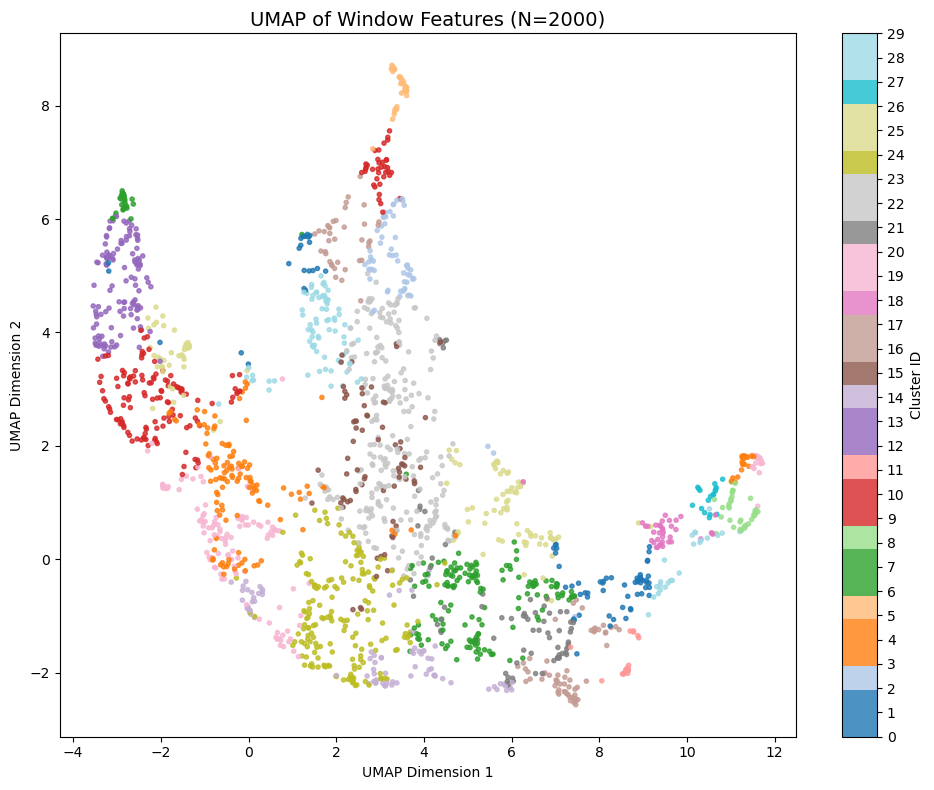

In [88]:
visualize_cluster_assignment(all_window_features_flat_scaled, all_cluster_assignments, K_CLUSTERS=K_CLUSTERS, N_SAMPLES=2000)

## UMAP of BoW Features

!! Doesn't look very promissing !!

In [89]:
bow_df.describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,...,BoW_20,BoW_21,BoW_22,BoW_23,BoW_24,BoW_25,BoW_26,BoW_27,BoW_28,BoW_29
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.034468,0.009814,0.033925,0.053731,0.010714,0.021531,0.061844,0.012422,0.017301,0.023378,...,0.050139,0.032022,0.050679,0.066706,0.081108,0.025525,0.037455,0.007615,0.016412,0.035273
std,0.016915,0.014898,0.017475,0.021479,0.012195,0.016076,0.026832,0.011097,0.011878,0.012536,...,0.020625,0.014879,0.024340,0.024000,0.038346,0.012300,0.019153,0.007548,0.011968,0.026619
min,0.007937,0.000000,0.002433,0.013793,0.000000,0.000000,0.007246,0.000000,0.000000,0.000000,...,0.012862,0.004167,0.005076,0.010309,0.012500,0.007117,0.003300,0.000000,0.000000,0.000000
25%,0.023725,0.000000,0.020881,0.040853,0.000541,0.011470,0.042420,0.003630,0.008066,0.014215,...,0.034217,0.021409,0.034424,0.049482,0.052579,0.014875,0.023466,0.001603,0.006451,0.015492
50%,0.031579,0.004329,0.029197,0.052192,0.007168,0.016234,0.058824,0.010753,0.016908,0.021429,...,0.047619,0.030928,0.046243,0.066667,0.072993,0.025000,0.035088,0.005698,0.014151,0.029221
75%,0.046583,0.010514,0.045516,0.066325,0.015365,0.027907,0.077697,0.017329,0.024166,0.028632,...,0.062323,0.043054,0.059276,0.082894,0.103497,0.032002,0.050380,0.013129,0.023991,0.054630
max,0.091241,0.075385,0.082305,0.142322,0.070755,0.085020,0.133652,0.058333,0.050682,0.062500,...,0.104762,0.070342,0.138947,0.137472,0.192354,0.062706,0.077170,0.035533,0.049536,0.114286


Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 606.41iter/s]


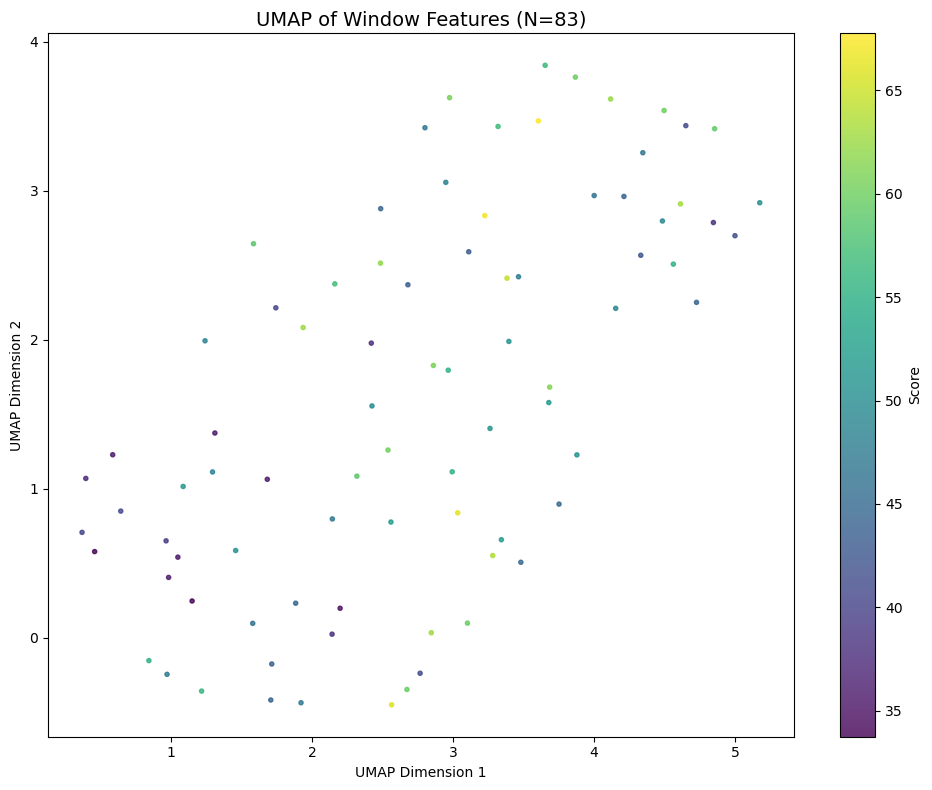

In [90]:
X_bow = bow_df.values

visualize_cluster_assignment(X_bow, np.array(bag_scores).flatten(), is_discrete=False)

# Let's have a closer look at the individual BoW features

In [124]:
# standardize the data using standard scaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

scaler = StandardScaler()
X_bow_scaled = scaler.fit_transform(X_bow)

scaled_bow_df = pd.DataFrame(X_bow_scaled, columns=bow_df.columns, index=bow_df.index)
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
pearson_corrs = []
spearman_corrs = []
for i in range(X_bow_scaled.shape[1]):
    pearson_corr, _ = pearsonr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    spearman_corr, _ = spearmanr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 BoW features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:6]
for idx in top_pearson_indices:
    print(f"BoW_{idx}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 BoW features by Pearson correlation:
BoW_2: Pearson r = 0.4741, Spearman rho = 0.4546
BoW_20: Pearson r = -0.4469, Spearman rho = -0.4398
BoW_24: Pearson r = -0.3973, Spearman rho = -0.3594
BoW_13: Pearson r = 0.3972, Spearman rho = 0.4220
BoW_22: Pearson r = 0.3760, Spearman rho = 0.4090
BoW_25: Pearson r = 0.3354, Spearman rho = 0.3519


Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 420.06iter/s]


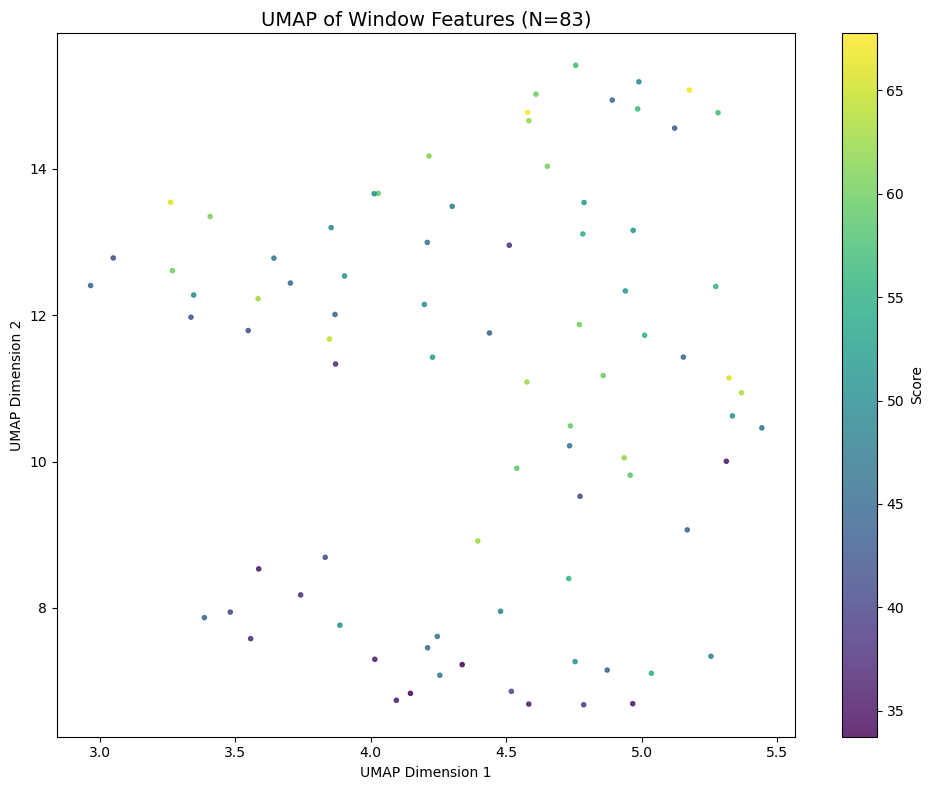

In [104]:
X_bow_filtered = X_bow[:, top_pearson_indices]
visualize_cluster_assignment(X_bow_filtered, np.array(bag_scores).flatten(), is_discrete=False)

In [106]:
# Assuming 'kmeans' is your trained model
centroids = kmeans.cluster_centers_
feature_names = ['PathRatio', 'Jerk', 'Curvature', 'Reversals', 'StdVel', 'TotalPath', 'MeanVel']

print("--- Negative Predictors (Novice Moves) ---")
for idx in [20, 24]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in [2, 13, 22, 25]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 20: {'PathRatio': np.float32(-0.16), 'Jerk': np.float32(-0.43), 'Curvature': np.float32(-0.36), 'Reversals': np.float32(-0.48), 'StdVel': np.float32(0.45), 'TotalPath': np.float32(0.39), 'MeanVel': np.float32(0.4)}
Cluster 24: {'PathRatio': np.float32(-0.14), 'Jerk': np.float32(-0.19), 'Curvature': np.float32(-0.11), 'Reversals': np.float32(-0.12), 'StdVel': np.float32(-0.11), 'TotalPath': np.float32(-0.16), 'MeanVel': np.float32(-0.16)}

--- Positive Predictors (Expert Moves) ---
Cluster 2: {'PathRatio': np.float32(2.96), 'Jerk': np.float32(0.52), 'Curvature': np.float32(0.14), 'Reversals': np.float32(0.57), 'StdVel': np.float32(-0.1), 'TotalPath': np.float32(-0.01), 'MeanVel': np.float32(-0.01)}
Cluster 13: {'PathRatio': np.float32(-0.24), 'Jerk': np.float32(-0.37), 'Curvature': np.float32(0.01), 'Reversals': np.float32(-0.12), 'StdVel': np.float32(4.0), 'TotalPath': np.float32(1.86), 'MeanVel': np.float32(2.02)}
Cluster 22: {'PathRa

# Hybrid Model : Combine top BoW features with global PCA features

In [127]:
df_total_metrics_pca = pd.read_csv("data/metrics/total_metrics_pca.csv")

df_total_metrics_pca.head(2)


,Participant Number,Case_Number,PC1,PC2,PC3,QRS_Overal
0,1,1,0.487489,-0.793460,0.334092,48.5
1,1,2,-2.287117,0.224301,0.090565,45.0


In [128]:
df_map = pd.read_csv("data/scores/vid_name_map.csv").rename(columns={"Unnamed: 0": "VideoName", "Case Number": "Case_Number"})
df_total_metrics_pca = pd.merge(df_total_metrics_pca, df_map, on=['Participant Number', 'Case_Number'])
df_total_metrics_pca

,Participant Number,Case_Number,PC1,PC2,PC3,QRS_Overal,VideoName
0,1,1,0.487489,-0.793460,0.334092,48.50,2024-01-15_13-18-23
1,1,2,-2.287117,0.224301,0.090565,45.00,2024-01-15_13-37-36
2,1,3,-1.109647,0.967259,0.037255,60.50,2024-01-15_14-03-23
3,2,1,5.351349,0.689718,-0.832712,39.25,2024-01-15_14-32-45
4,2,2,2.697762,-0.369234,-0.824595,38.00,2024-01-15_15-05-31
...,...,...,...,...,...,...,...
78,28,2,-2.111659,-0.721672,-0.144239,59.75,2024-01-24_16-04-43
79,28,3,-1.597115,-0.182899,0.211097,56.50,2024-01-24_16-21-06
80,29,1,1.829308,-0.301507,0.457147,40.75,2024-01-24_16-52-58
81,29,2,0.438817,-0.920272,0.058260,50.25,2024-01-24_17-19-03


In [129]:
top_bow_df = scaled_bow_df.iloc[:, top_pearson_indices]
top_bow_df['Participant Number'] = [int(idx[1]) for idx in top_bow_df.index]

merged_feature_df = pd.merge(df_total_metrics_pca, top_bow_df.reset_index(), on='VideoName').drop(columns=['Participant Number_y', 'Participant Number_x'])
merged_feature_df

/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_61460/1320469613.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_bow_df['Participant Number'] = [int(idx[1]) for idx in top_bow_df.index]


,Case_Number,PC1,PC2,PC3,QRS_Overal,VideoName,SurgeonID,BoW_2,BoW_20,BoW_24,BoW_13,BoW_22,BoW_25
0,1,0.487489,-0.793460,0.334092,48.50,2024-01-15_13-18-23,1,0.026859,1.941835,0.578974,1.320646,-0.235821,0.725175
1,2,-2.287117,0.224301,0.090565,45.00,2024-01-15_13-37-36,1,-1.368635,0.525575,-0.529830,2.106901,-1.884934,-0.842217
2,3,-1.109647,0.967259,0.037255,60.50,2024-01-15_14-03-23,1,-0.760806,-1.579896,-0.730787,0.985654,1.207065,0.332103
3,1,5.351349,0.689718,-0.832712,39.25,2024-01-15_14-32-45,2,-0.510823,0.609319,2.555214,-0.918678,-0.584641,-1.490136
4,2,2.697762,-0.369234,-0.824595,38.00,2024-01-15_15-05-31,2,-0.853899,-0.000979,0.595872,-1.501227,-1.058938,-1.404555
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,2,-2.111659,-0.721672,-0.144239,59.75,2024-01-24_16-04-43,28,0.490961,-1.065243,0.347170,-0.158604,0.829814,-0.930347
79,3,-1.597115,-0.182899,0.211097,56.50,2024-01-24_16-21-06,28,1.028680,0.080654,-0.141953,0.535015,2.680873,1.170869
80,1,1.829308,-0.301507,0.457147,40.75,2024-01-24_16-52-58,29,-0.706488,0.722985,1.693913,-1.386568,-0.630165,-0.960725
81,2,0.438817,-0.920272,0.058260,50.25,2024-01-24_17-19-03,29,-0.947500,0.216865,0.908143,-1.466144,-0.741022,-0.837684


Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 107.25it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7370
Overall MAE: 5.0055
Overall Std Dev of Errors: 3.8420

--- Per-Fold Performance Summary ---
           Train_MAE   Test_MAE  Test_Corr
SurgeonID                                 
1           4.483444   6.264849   0.242420
2           4.568134   4.323318   0.766251
3           4.372983  11.761488   0.715871
4           4.616409   2.934934  -0.685477
5           4.514605   6.721534   0.462703
6           4.591319   3.649602   0.427720
7           4.418862   8.817250  -0.827899
9           4.534444   6.204821   0.486790
10          4.622613   3.378840   0.955447
11          4.640816   2.599613  -0.310309
12          4.639602   3.285529  -0.094961
13          4.605646   4.405184   0.985335
14          4.434874   9.183228  -0.621885
15          4.581370   4.409478   0.999732
16          4.371652  10.013589  -0.978442
17          4.618571   3.177611   0.895736
18          4.448366   7.833339   0.932322
19          

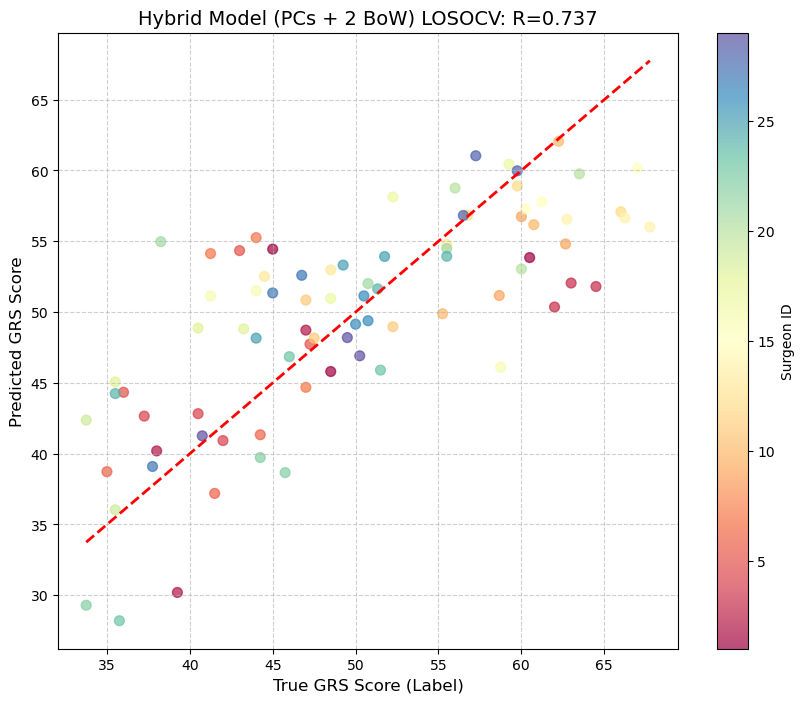

In [179]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in merged_feature_df.columns if col.startswith('PC') or col in ['BoW_2', 'BoW_20']]
X = merged_feature_df[feature_cols].values
y = merged_feature_df['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = merged_feature_df['SurgeonID'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = pearsonr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Hybrid Model (PCs + 2 BoW) LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.colorbar(scatter, label='Surgeon ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [177]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

# --- 1. Prepare Data ---

# Ensure all your feature columns are numerical and correctly identified
feature_cols = [col for col in merged_feature_df.columns if col.startswith('PC') or col in ['BoW_2', 'BoW_20']]#, 'BoW_20', 'BoW_22', 'BoW_25']]
X = merged_feature_df[feature_cols].values
y = merged_feature_df['QRS_Overal'].values  # Assuming your score column is named GRS_Score

# Extract the Surgeon IDs for the folds
# Re-extracting the surgeon IDs from the index (assuming your index is unique video names now)
# Find the actual column containing Surgeon ID
if 'SurgeonID' in merged_feature_df.columns:
    surgeon_ids = merged_feature_df['SurgeonID'].values
else:
    # Use the column you created before the merge, e.g., 'Participant Number'
    # Assuming 'Participant Number' holds the unique surgeon/participant identifier
    surgeon_ids = merged_feature_df['Participant Number'].values # ADJUST THIS TO YOUR ACTUAL SURGEON ID COLUMN!

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # 3. Train Model
    # A low alpha (less regularization) might be okay with only 13 features
    # but a small amount of regularization is still good practice.
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_pred = model.predict(X_test)
    predictions.extend(y_pred)
    true_scores.extend(y_test)

# --- 4. Evaluate Final Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = pearsonr(final_true_scores, final_predictions)

print("\n-------------------------------------------------")
print(f"Hybrid Model (Ridge in LOSOCV) Performance:")
print(f"Baseline Corr (Global PCs): 0.72")
print(f"Hybrid Correlation (Global+BoW): {hybrid_corr:.4f}")
print(f"Hybrid MAE: {hybrid_mae:.4f}")
print(f"Hybrid Std of Errors: {hybrid_std:.4f}")
print("-------------------------------------------------")

# Trigger a relevant diagram to show the relationship
#

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 236.20it/s]


-------------------------------------------------
Hybrid Model (Ridge in LOSOCV) Performance:
Baseline Corr (Global PCs): 0.72
Hybrid Correlation (Global+BoW): 0.7370
Hybrid MAE: 5.0055
Hybrid Std of Errors: 3.8420
-------------------------------------------------


In [143]:
top_pearson_indices

array([ 2, 20, 24, 13, 22, 25])

In [142]:
# check colinearity between PC features and BoW features
# what is the correlation between PC1, PC2, PC3 and the top BoW features
for pc_col in ['PC1', 'PC2', 'PC3']:
    for bow_col in [col for col in top_bow_df.columns if col.startswith('BoW_')]:
        pearson_corr, _ = pearsonr(merged_feature_df[pc_col], merged_feature_df[bow_col])
        spearman_corr, _ = spearmanr(merged_feature_df[pc_col], merged_feature_df[bow_col])
        print(f"{pc_col} vs {bow_col}: Pearson r = {pearson_corr:.4f}, Spearman rho = {spearman_corr:.4f}")

PC1 vs BoW_2: Pearson r = -0.4075, Spearman rho = -0.4075
PC1 vs BoW_20: Pearson r = 0.4062, Spearman rho = 0.3590
PC1 vs BoW_24: Pearson r = 0.5294, Spearman rho = 0.4425
PC1 vs BoW_13: Pearson r = -0.4715, Spearman rho = -0.4836
PC1 vs BoW_22: Pearson r = -0.2972, Spearman rho = -0.3397
PC1 vs BoW_25: Pearson r = -0.3329, Spearman rho = -0.3435
PC2 vs BoW_2: Pearson r = 0.2607, Spearman rho = 0.1789
PC2 vs BoW_20: Pearson r = -0.1641, Spearman rho = -0.1481
PC2 vs BoW_24: Pearson r = -0.5504, Spearman rho = -0.6206
PC2 vs BoW_13: Pearson r = 0.3372, Spearman rho = 0.3384
PC2 vs BoW_22: Pearson r = 0.2753, Spearman rho = 0.1708
PC2 vs BoW_25: Pearson r = 0.0360, Spearman rho = 0.0658
PC3 vs BoW_2: Pearson r = -0.2514, Spearman rho = -0.3778
PC3 vs BoW_20: Pearson r = 0.1090, Spearman rho = 0.0704
PC3 vs BoW_24: Pearson r = -0.1516, Spearman rho = -0.0986
PC3 vs BoW_13: Pearson r = 0.3704, Spearman rho = 0.3348
PC3 vs BoW_22: Pearson r = -0.2198, Spearman rho = -0.2762
PC3 vs BoW_25: P